# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [48]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [26]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
print(tox.shape)
tox.head()

(7376, 2)


,smiles,ld_50
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,BrC(Br)Br,2.343
2,C=CBr,2.330
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,S=C=Nc1ccc(Br)cc1,2.729


2) Calculate descriptors

In [ ]:
descriptor_names = [d[0] for d in Descriptors._descList] # iterate through the whole list of descriptors from rdkit

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [desc[1](mol) for desc in Descriptors._descList]

X_md = tox.smiles.apply(calc_descriptors)

X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names)

valid_idx = X_md.dropna().index
X_md = X_md.loc[valid_idx].reset_index(drop=True)
y = tox["ld_50"].loc[valid_idx].reset_index(drop=True)
X_md = X_md.dropna(axis=1)

print(X_md.shape)
print(y.shape)

(7376, 217)
(7376,)


In [50]:
X_md.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0,0,0,0,0,0,0,0,0,0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0,0,0,0,0,0,0,0,0,0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0,0,0,0,0,0,0,0,0,0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0,0,0,0,0,0,0,0,0,0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0,0,0,0,0,0,0,0,0,0


3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

In [28]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold).astype(str)

OneHotEncoder for the Murcko scaffolds:

In [29]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_scaf = ohe.fit_transform(tox["scaffold"].values.reshape(-1, 1))
X_scaf = pd.DataFrame(X_scaf, columns=ohe.get_feature_names_out(["scaffold"]))

X_scaf = X_scaf.loc[valid_idx].reset_index(drop=True)
print(X_scaf.shape)

(7376, 1677)


Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [30]:
functional_groups = {
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "aromatic_ring": "a",
    "nitro": "[NX3](=O)=O",
    "halogen": "[F,Cl,Br,I]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "epoxide": "[OX2r3]",
    "thiol": "[SX2H]",
    "ester": "[#6][CX3](=O)[OX2][#6]",
    "amide": "[NX3][CX3](=O)",
}

In [31]:
patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)
X_fg = X_fg.loc[valid_idx].reset_index(drop=True)
print(X_fg.shape)

(7376, 10)


4.

In [32]:
X_md_scaf = pd.concat([X_md, X_scaf], axis=1)
X_md_scaf_fg = pd.concat([X_md, X_scaf, X_fg], axis=1)

feature_sets = {
    "X_md": X_md,
    "X_scaf": X_scaf,
    "X_fg": X_fg,
    "X_md_scaf": X_md_scaf,
    "X_md_scaf_fg": X_md_scaf_fg,
}

results = {}
for name, X in feature_sets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    r2 = r2_score(y_test, rf.predict(X_test))
    results[name] = round(r2, 4)
    print(f"{name:20s} R² = {r2:.4f}")

X_md                 R² = 0.6170
X_scaf               R² = 0.2074
X_fg                 R² = 0.1169
X_md_scaf            R² = 0.6159
X_md_scaf_fg         R² = 0.6132


5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

In [33]:
from sklearn.feature_selection import VarianceThreshold

best_name = max(results, key=results.get)
X_best = feature_sets[best_name].copy()
print(f"Best: {best_name} (R²={results[best_name]})")

Best: X_md (R²=0.617)


In [ ]:
# Variance Threshold
sel = VarianceThreshold(threshold=0.01)
X_pruned = pd.DataFrame(
    sel.fit_transform(X_best),
    columns=X_best.columns[sel.get_support()]
)
print(f"After VarianceThreshold: {X_pruned.shape}")

After VarianceThreshold: (7376, 192)


In [35]:
# correlation
corr_matrix = X_pruned.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
X_pruned = X_pruned.drop(columns=drop_cols)
print(f"After correlation filter: {X_pruned.shape}")

After correlation filter: (7376, 150)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_pruned, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
r2_pruned = r2_score(y_test, rf.predict(X_test))
print(f"R² after pruning: {r2_pruned:.4f}  (was {results[best_name]:.4f})")

R² after pruning: 0.6175  (was 0.6170)


6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [37]:
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

fps_mol = [gen.GetFingerprint(Chem.MolFromSmiles(s))
           for s in tox["smiles"].loc[valid_idx]]

fps_scaf = [gen.GetFingerprint(Chem.MolFromSmiles(s))
            for s in tox["scaffold"].loc[valid_idx]]

7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [38]:
# molecular fingerprints
fps = fps_mol

dists = []
nfps = len(fps)
cutoff = 0.6

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1-x for x in sims])

clusters = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters))

Number of clusters: 2408


In [39]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in clusters if len(c) >= 5]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 334
mean size: 12.769461077844312
max size: 112
singletons: 0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [40]:
# convert fingerprints to numpy
fp_array = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

In [41]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

umap_emb = reducer.fit_transform(fp_array)

/Users/mircodill/DSA104/venv3.9/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

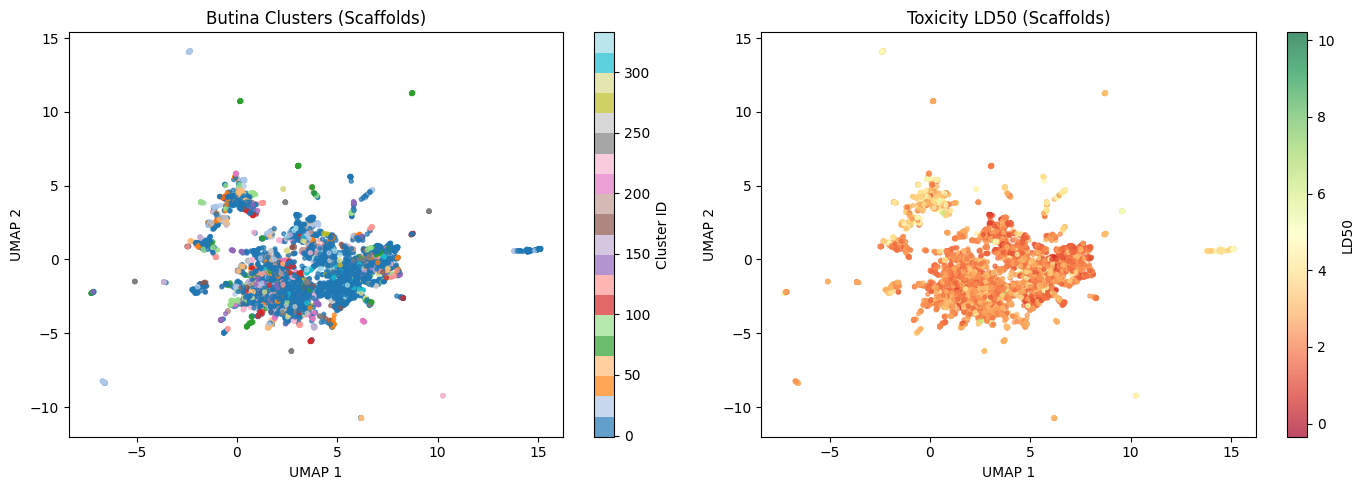

In [ ]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sc1 = ax1.scatter(
    umap_emb[:,0],
    umap_emb[:,1],
    c=butina_labels,
    cmap="tab20",
    s=8,
    alpha=0.7)
ax1.set(title="Butina Clusters (Fingerprint)", xlabel="UMAP 1", ylabel="UMAP 2")
plt.colorbar(sc1, ax=ax1, label="Cluster ID")

sc2 = ax2.scatter(
    umap_emb[:,0],
    umap_emb[:,1],
    c=tox["ld_50"].values,
    cmap="RdYlGn",
    s=8,
    alpha=0.7)
ax2.set(title="Toxicity LD50 (Fingerprints)", xlabel="UMAP 1", ylabel="UMAP 2")
plt.colorbar(sc2, ax=ax2, label="LD50")

plt.tight_layout()
plt.show()

8.

In [43]:
# Scaffolds 
fps = fps_scaf

dists = []
nfps = len(fps)
cutoff = 0.6

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1-x for x in sims])

clusters = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters))

Number of clusters: 747


In [44]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in clusters if len(c) >= 5]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 161
mean size: 40.27329192546584
max size: 1936
singletons: 0


In [45]:
# convert fingerprints to numpy
fp_array = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

In [46]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

umap_emb = reducer.fit_transform(fp_array)

/Users/mircodill/DSA104/venv3.9/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


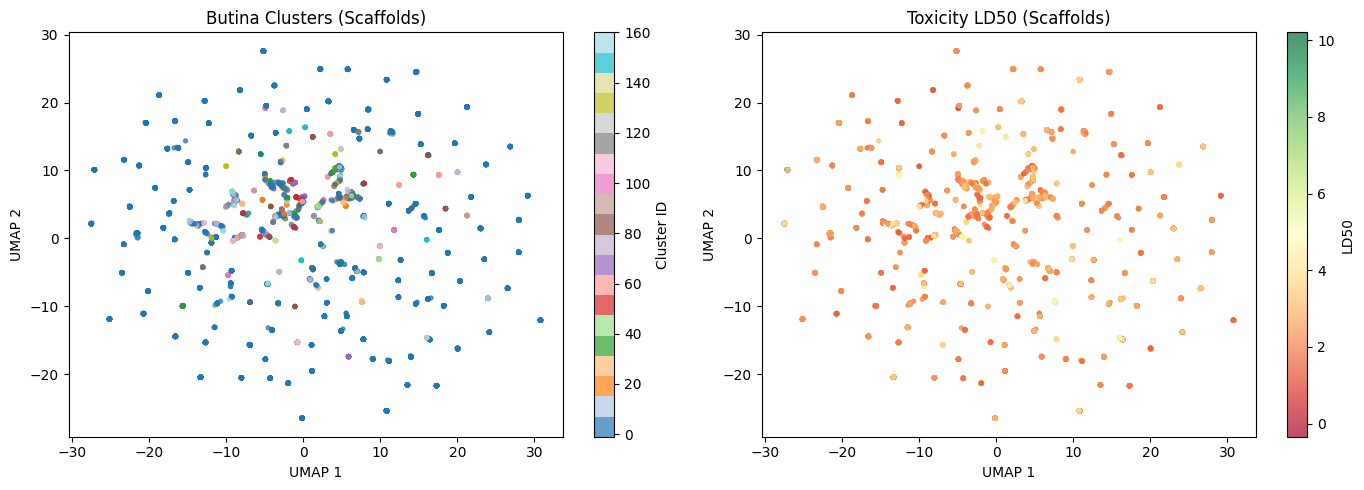

In [47]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sc1 = ax1.scatter(
    umap_emb[:,0],
    umap_emb[:,1],
    c=butina_labels,
    cmap="tab20",
    s=8,
    alpha=0.7)
ax1.set(title="Butina Clusters (Scaffolds)", xlabel="UMAP 1", ylabel="UMAP 2")
plt.colorbar(sc1, ax=ax1, label="Cluster ID")

sc2 = ax2.scatter(
    umap_emb[:,0],
    umap_emb[:,1],
    c=tox["ld_50"].values,
    cmap="RdYlGn",
    s=8,
    alpha=0.7)
ax2.set(title="Toxicity LD50 (Scaffolds)", xlabel="UMAP 1", ylabel="UMAP 2")
plt.colorbar(sc2, ax=ax2, label="LD50")

plt.tight_layout()
plt.show()

#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?
2) Is the One-Hot Encoding needed in this case?
3) Did the feature filtering (variance, correlation) have an improving effect? Explain!
4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure compatibility with other models? How would the function / pipeline look schematically?
5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.
6) When might scaffolding prove useful?
7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?


1. X_md performed best, scaffolds and functional groups alone were quite poor. combining them did not really help either. adding X_scaf and X_fg to X_md barely changed anything. probably because the OHE scaffold matrix is huge and very sparse, which doesnt help the RF much. Molecular descriptors already capture most of the relevant information.

2. for the functional groups not really, they're already binary (0/1). for scaffolds yes, since they are strings and models cannot work with those directly. but rather no, because it did not really contribute anysthing.

3. not really, R2 went from 0.6170 to 0.6175. altough the number of features dropped from 217 to 150, so the model is leaner. RF are generally robust to irrelevant features so a big improvement wasn't expected. RF already has built in sorting for important features, with different models, maybe a bigger issue.

4. code each feature set in a pipeline with a VarianceThreshold, correlation filter, and the RF. a dict of named pipelines to loop over them cleanly and ensure the same preprocessing for each. is compatible with any sklearn estimator.

5. scaffolds ignores sidechains so many molecules map to the same scaffold. the space collapses into fewer distinct points (747 vs 2408 clusters). molecule fingerprints capture more diversity. so using the scaffold, we could reach more distinc clusters instead of large amounts of singletons. Butina with a fixed cutoff on full molecules is therefore more detailed, scaffold-based clustering groups things more coarsely by structural elemeents.

6. e.g. when you specifically care about shared structural elements, maybe for clustering of similar chemicals

7. there is some clustering visible in the UMAP toxicity map, but not really clean. region with higher/lower LD50 values exist but there is a lot of overlap. structure has some predictive power but toxicity is also influenced by factors not captured in fingerprints.